# Boost Converter — Projeto e Controle Cascateado

Este notebook cobre o projeto completo de um conversor Boost com **controle em cascata (dois laços)**:

1. **Especificações e projeto de componentes** (L, C)
2. **Modelo de pequenos sinais** — Gvd(s) e Gid(s) com derivação correta
3. **Análise da planta** — Bode, zero RHP, limitações do laço único
4. **Projeto do controlador cascateado**
   - Laço interno: corrente no indutor (PI rápido)
   - Laço externo: tensão de saída (PI lento)
5. **Verificação de estabilidade** — margens de ganho e fase
6. **Simulação** no PulsimCore — malha aberta e malha fechada cascateada

---

### Topologia

```
     Rsense   L          D1
Vin──RRRR──LLLL──n_sw──►|──n_out──┬── Vout
     n_sense              │        │
                         M1       C  R_load
                          │        │
                         GND──────┴── GND
```

**Relação de conversão (CCM ideal):** $V_{out} = \dfrac{V_{in}}{1-D} = \dfrac{V_{in}}{D'}$

In [12]:
from pathlib import Path
import sys

_root = Path.cwd()
for _ in range(6):
    for _rel in (('build-test', 'python'), ('build', 'python')):
        candidate = _root / _rel[0] / _rel[1]
        if candidate.is_dir():
            cstr = str(candidate)
            if cstr not in sys.path:
                sys.path.insert(0, cstr)
    _root = _root.parent

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pulsim as ps
import time

print(f'PulsimCore v{ps.__version__}')

Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/PulsimCore/build/cp311-cp311-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/PulsimCore/build/cp311-cp311-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/PulsimCore/build/cp311-cp311-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/PulsimCore/build/cp311-cp311-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/PulsimCore/build/cp311-cp311-macosx_26_0_arm64
Running cmake --build & --install in /Users/lgili/Documents/01 - Codes/01 - Github/PulsimCore/build/cp311-cp311-macosx_26_0_arm64
PulsimCore v0.7.8


In [13]:
def run_transient_compat(circuit, t_start, t_stop, dt, x0=None, newton_options=None):
    """Helper de compatibilidade: retorna (times, states, success, msg)."""
    if hasattr(ps, 'SimulationOptions') and hasattr(ps, 'Simulator'):
        try:
            opts = ps.SimulationOptions()
            opts.tstart = float(t_start)
            opts.tstop = float(t_stop)
            opts.dt = float(dt)
            if hasattr(opts, 'dt_min'):
                opts.dt_min = min(float(opts.dt_min), float(dt))
            if hasattr(opts, 'dt_max'):
                opts.dt_max = max(float(opts.dt_max), float(dt))
            if newton_options is not None:
                opts.newton_options = newton_options
            sim = ps.Simulator(circuit, opts)
            result = sim.run_transient() if x0 is None else sim.run_transient(x0)
            return result.time, result.states, bool(result.success), str(result.message)
        except Exception:
            pass
    # Fallback legacy API
    args = [] if x0 is None else [x0]
    if newton_options is not None:
        args.append(newton_options)
    return ps.run_transient(circuit, t_start, t_stop, dt, *args)

In [14]:
# ============================================================
# ESPECIFICAÇÕES
# ============================================================
Vin    = 12.0      # Tensão de entrada [V]
Vout   = 24.0      # Tensão de saída [V]
Pout   = 50.0      # Potência de saída [W]
fsw    = 100e3     # Frequência de chaveamento [Hz]
Tsw    = 1 / fsw

# Ponto de operação nominal
D      = 1.0 - Vin / Vout   # duty cycle nominal
Dp     = 1.0 - D             # D' = 1 - D
Iout   = Pout / Vout
R_load = Vout / Iout          # resistência de carga
IL_nom = Iout / Dp            # corrente nominal no indutor (CCM ideal)

# Componentes
L      = 100e-6   # indutor [H]
C      = 100e-6   # capacitor de saída [F]
Rsense = 0.01     # resistor de sensoriamento de corrente [Ω]

print('ESPECIFICAÇÕES')
print(f'  Vin={Vin}V  Vout={Vout}V  Pout={Pout}W  fsw={fsw/1e3:.0f}kHz')
print(f'  D={D:.2%}  D\' ={Dp:.2%}')
print(f'  Iout={Iout:.3f}A  IL_nom={IL_nom:.3f}A  R_load={R_load:.2f}Ω')
print(f'  L={L*1e6:.0f}µH  C={C*1e6:.0f}µF  Rsense={Rsense*1e3:.0f}mΩ')

ESPECIFICAÇÕES
  Vin=12.0V  Vout=24.0V  Pout=50.0W  fsw=100kHz
  D=50.00%  D' =50.00%
  Iout=2.083A  IL_nom=4.167A  R_load=11.52Ω
  L=100µH  C=100µF  Rsense=10mΩ


## Modelo de Pequenos Sinais (CCM)

### Equações de estado linearizadas

Em torno do ponto de operação $(D, V_{out}, I_L)$, com $\hat{v}_{in}=0$:

$$L\,\frac{d\hat{i}_L}{dt} = -D'\hat{v}_{out} + V_{out}\,\hat{d}$$

$$C\,\frac{d\hat{v}_{out}}{dt} = D'\hat{i}_L - \frac{\hat{v}_{out}}{R} - I_L\,\hat{d}$$

onde $D' = 1-D$, $I_L = V_{out}/(D'R)$.

### Função de transferência tensão/duty — $G_{vd}(s)$

Resolvendo o sistema de equações:

$$\boxed{G_{vd}(s) = \frac{\hat{v}_{out}}{\hat{d}} = \frac{V_{out}}{D'} \cdot \frac{1 - s/\omega_{z,\text{RHP}}}{1 + s/(Q\omega_0) + s^2/\omega_0^2}}$$

| Parâmetro | Expressão | Observação |
|---|---|---|
| $\omega_0 = D'/\sqrt{LC}$ | Ressonância do filtro LC | Equivale ao LC *transferido* para o secundário |
| $Q = D'R\sqrt{C/L}$ | Fator de qualidade | Alto Q → pico de ressonância |
| $\omega_{z,\text{RHP}} = D'^2 R/L$ | **Zero RHP** | Limita duramente a banda do laço |

> ⚠️ O zero RHP impõe a regra prática: $f_c < f_{z,\text{RHP}}/3$

### Função de transferência corrente/duty — $G_{id}(s)$

Resolvendo para $\hat{i}_L/\hat{d}$ (eliminando $\hat{v}_{out}$):

$$\boxed{G_{id}(s) = \frac{\hat{i}_L}{\hat{d}} = \frac{V_{out}}{L} \cdot \frac{s + \omega_{z,\text{LHP}}}{s^2 + s/(RC) + \omega_0^2}}$$

| Parâmetro | Expressão | Observação |
|---|---|---|
| $\omega_{z,\text{LHP}} = 2/(RC)$ | **Zero LHP** | Mínima fase — não limita banda |
| Pólos | Mesmos que $G_{vd}$ | Ressonância $\omega_0$, fator $Q$ |

> ✅ $G_{id}$ **não tem zero RHP** → laço interno pode ter banda muito maior!

### Planta efetiva do laço externo (laço interno fechado)

Com o laço de corrente fechado ($\hat{i}_L \approx \hat{i}_{L,ref}$), a equação do nó de saída simplifica:

$$C\,s\hat{v}_{out} = D'\hat{i}_{L,ref} - \hat{v}_{out}/R \quad\Rightarrow\quad \boxed{G_{\text{eff}}(s) = \frac{\hat{v}_{out}}{\hat{i}_{L,ref}} = \frac{D'R}{1 + sRC}}$$

Planta de **primeira ordem** sem zero RHP — o laço externo pode ser projetado de forma simples.

In [15]:
# ============================================================
# PARÂMETROS DO MODELO DE PEQUENOS SINAIS
# ============================================================
omega0     = Dp / np.sqrt(L * C)           # [rad/s]
f0         = omega0 / (2*np.pi)             # [Hz]
Q          = Dp * R_load * np.sqrt(C / L)  # adim

# RHP zero de Gvd
omega_z_rhp = Dp**2 * R_load / L           # [rad/s]
f_z_rhp     = omega_z_rhp / (2*np.pi)      # [Hz]

# LHP zero de Gid
omega_z_lhp = 2.0 / (R_load * C)           # [rad/s] = 2/tau
f_z_lhp     = omega_z_lhp / (2*np.pi)      # [Hz]

# Ganhos DC
Gvd_DC = Vout / Dp                          # [V/duty]
Gid_DC = 2.0 * Vout / (Dp**2 * R_load)     # [A/duty]  = 2*Vout/(D'^2*R)

# Verificação analítica de Gid_DC:
# Gid(0) = (Vout/L)*(omega_z_lhp) / omega0^2
#         = (Vout/L)*(2/(RC)) / (D'^2/(LC)) = 2*Vout/(D'^2*R)  ✓

print('PARÂMETROS DE PEQUENOS SINAIS')
print(f'  Freq. ressonância:  f0 = {f0:.1f} Hz   ω0 = {omega0:.1f} rad/s')
print(f'  Fator de qualidade: Q  = {Q:.3f}')
print(f'  Zero RHP (Gvd):    f_z_rhp = {f_z_rhp:.0f} Hz  →  fc_max = {f_z_rhp/3:.0f} Hz')
print(f'  Zero LHP (Gid):    f_z_lhp = {f_z_lhp:.0f} Hz')
print(f'  Gvd_DC = {Gvd_DC:.2f} V/duty')
print(f'  Gid_DC = {Gid_DC:.4f} A/duty')

PARÂMETROS DE PEQUENOS SINAIS
  Freq. ressonância:  f0 = 795.8 Hz   ω0 = 5000.0 rad/s
  Fator de qualidade: Q  = 5.760
  Zero RHP (Gvd):    f_z_rhp = 4584 Hz  →  fc_max = 1528 Hz
  Zero LHP (Gid):    f_z_lhp = 276 Hz
  Gvd_DC = 48.00 V/duty
  Gid_DC = 16.6667 A/duty


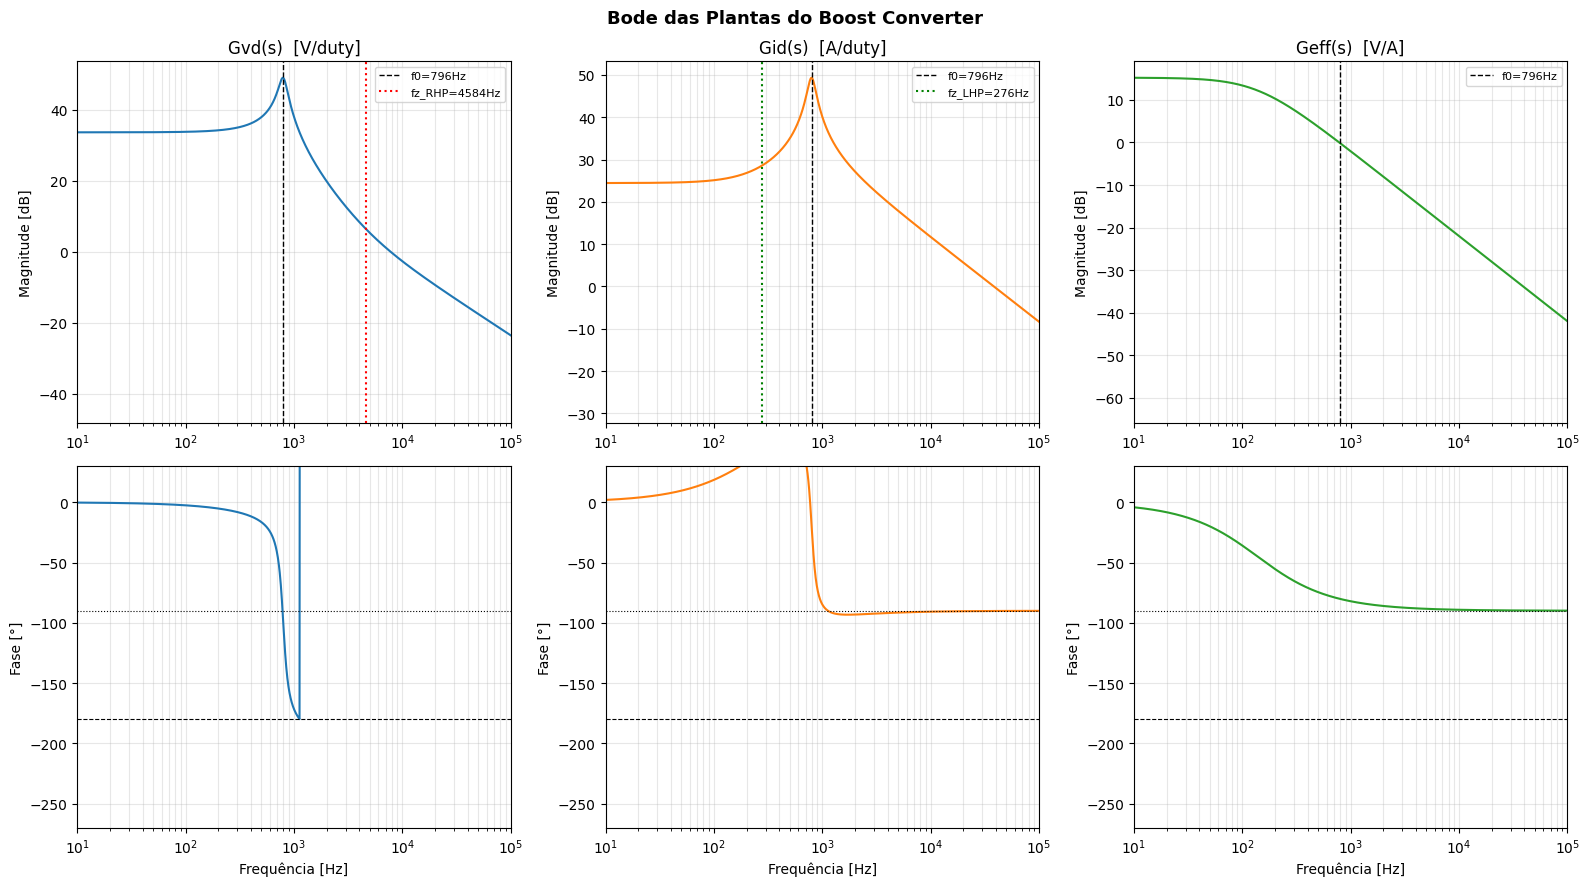

In [16]:
# ============================================================
# BODE DAS PLANTAS
# ============================================================
f_plot = np.logspace(1, 6, 2000)
w_plot = 2*np.pi*f_plot
s      = 1j * w_plot

# Gvd(s) = (Vout/D') * (1 - s/wz_rhp) / (1 + s/(Q*w0) + s^2/w0^2)
Gvd_s = Gvd_DC * (1 - s/omega_z_rhp) / (1 + s/(Q*omega0) + s**2/omega0**2)

# Gid(s) = (Vout/L) * (s + wz_lhp) / (s^2 + s/(RC) + w0^2)
tau_RC = R_load * C  # = 1/868 rad/s
Gid_s  = (Vout/L) * (s + omega_z_lhp) / (s**2 + s/tau_RC + omega0**2)

# Geff(s) = D'*R / (1 + sRC)   (planta efetiva do laço externo)
Geff_s = (Dp * R_load) / (1 + s * R_load * C)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
titles  = ['Gvd(s)  [V/duty]', 'Gid(s)  [A/duty]', 'Geff(s)  [V/A]']
funcs   = [Gvd_s,   Gid_s,     Geff_s]
colors  = ['tab:blue', 'tab:orange', 'tab:green']

for col, (tf, title, color) in enumerate(zip(funcs, titles, colors)):
    mag_dB = 20*np.log10(np.abs(tf))
    ph_deg = np.degrees(np.angle(tf))

    ax_m = axes[0, col]
    ax_m.semilogx(f_plot, mag_dB, color=color)
    ax_m.axvline(f0,         color='k',       ls='--', lw=1, label=f'f0={f0:.0f}Hz')
    if col == 0:
        ax_m.axvline(f_z_rhp, color='red',    ls=':',  lw=1.5, label=f'fz_RHP={f_z_rhp:.0f}Hz')
    if col == 1:
        ax_m.axvline(f_z_lhp, color='green',  ls=':',  lw=1.5, label=f'fz_LHP={f_z_lhp:.0f}Hz')
    ax_m.set_title(title)
    ax_m.set_ylabel('Magnitude [dB]')
    ax_m.legend(fontsize=8)
    ax_m.grid(True, which='both', alpha=0.3)
    ax_m.set_xlim([10, 1e5])

    ax_p = axes[1, col]
    ax_p.semilogx(f_plot, ph_deg, color=color)
    ax_p.axhline(-180, color='k', ls='--', lw=0.8)
    ax_p.axhline(-90,  color='k', ls=':',  lw=0.8)
    ax_p.set_xlabel('Frequência [Hz]')
    ax_p.set_ylabel('Fase [°]')
    ax_p.set_ylim([-270, 30])
    ax_p.grid(True, which='both', alpha=0.3)
    ax_p.set_xlim([10, 1e5])

plt.suptitle('Bode das Plantas do Boost Converter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Projeto do Controle Cascateado

### Arquitetura

```
Vref ──►[Σ]──► PIv ──► iL_ref ──►[Σ]──► PIi ──► d (duty)
         ↑ -                        ↑ -
        Vout (medido)              iL  (medido)
```

| Laço | Planta | Controlador | Restrição |
|---|---|---|---|
| Interno (corrente) | $G_{id}(s)$ — sem RHP zero | P (+ FF) | $f_{c,i} = f_{sw}/10$ |
| Externo (tensão) | $G_{eff}(s)$ — 1ª ordem, sem RHP zero | PI | $f_{c,v} = f_{c,i}/10$ |

### Projeto do laço interno (corrente)

Para $\omega_{c,i} \gg \omega_0$, a resposta indutiva domina:
$$|G_{id}(j\omega_{c,i})| \approx \frac{V_{out}}{L \cdot \omega_{c,i}}$$

Ganho proporcional para cruzamento em $\omega_{c,i}$:
$$\boxed{K_{p,i} = \frac{L \cdot \omega_{c,i}}{V_{out}}}$$

### Projeto do laço externo (tensão)

Com laço interno fechado ($G_{cl,i}\approx 1$ para $\omega \ll \omega_{c,i}$), a planta efetiva é $G_{eff}(s)$.

Ganho proporcional para cruzamento em $\omega_{c,v}$:
$$\boxed{K_{p,v} = \frac{1}{|G_{eff}(j\omega_{c,v})|} = \frac{\sqrt{1+(\omega_{c,v}RC)^2}}{D'R}}$$

Zero do integrador em $\omega_{i,v} = \omega_{c,v}/10$ (adiciona 84° de fase):
$$\boxed{K_{i,v} = K_{p,v} \cdot \omega_{i,v}}$$

In [17]:
# ============================================================
# PROJETO DOS CONTROLADORES
# ============================================================

# --- Laço INTERNO (corrente) ---
f_ci      = fsw / 10.0                      # frequência de cruzamento [Hz]
omega_ci  = 2*np.pi*f_ci

# Ganho exato em omega_ci (não apenas aproximação)
s_ci      = 1j * omega_ci
Gid_at_ci = (Vout/L) * (s_ci + omega_z_lhp) / (s_ci**2 + s_ci/tau_RC + omega0**2)
Gid_mag_ci = abs(Gid_at_ci)
Gid_ph_ci  = np.degrees(np.angle(Gid_at_ci))

Kp_i  = 1.0 / Gid_mag_ci          # [duty/A]
# Aproximação analítica (confirma): Kp_i ≈ L*omega_ci/Vout
Kp_i_approx = L * omega_ci / Vout
PM_inner    = 180.0 + Gid_ph_ci   # margem de fase com controlador P

print('LAÇO INTERNO — Corrente no Indutor')
print(f'  Alvo: fci = {f_ci/1e3:.0f} kHz')
print(f'  |Gid(j*wci)| = {Gid_mag_ci:.4f} A/duty')
print(f'  Fase(Gid) = {Gid_ph_ci:.1f}°')
print(f'  Kp_i = {Kp_i:.4f} duty/A')
print(f'  Kp_i (aprox L*wci/Vout) = {Kp_i_approx:.4f} duty/A')
print(f'  Margem de fase (P puro) = {PM_inner:.1f}°')

print()

# --- Laço EXTERNO (tensão) ---
f_cv      = f_ci / 10.0                     # frequência de cruzamento [Hz]
omega_cv  = 2*np.pi*f_cv

s_cv      = 1j * omega_cv
Geff_at_cv = (Dp * R_load) / (1 + s_cv * R_load * C)
Geff_mag_cv = abs(Geff_at_cv)
Geff_ph_cv  = np.degrees(np.angle(Geff_at_cv))

# Expressão analítica:
# |Geff(j*wcv)| = Dp*R / sqrt(1 + (wcv*RC)^2)
Geff_mag_check = Dp*R_load / np.sqrt(1 + (omega_cv*R_load*C)**2)

Kp_v      = 1.0 / Geff_mag_cv               # [A/V]
omega_iv  = omega_cv / 10.0                  # zero do integrador
f_iv      = omega_iv / (2*np.pi)
Ki_v      = Kp_v * omega_iv                  # [A/(V·s)]

# Fase do PI externo + planta efetiva no cruzamento
ph_PIv_at_cv  = np.degrees(np.arctan(omega_cv/omega_iv)) - 90.0
ph_inner_lag  = -(omega_cv/omega_ci) * 90.0  # atraso do laço interno (1ª ordem)
PM_outer_total = 180.0 + Geff_ph_cv + ph_PIv_at_cv + ph_inner_lag

print('LAÇO EXTERNO — Tensão de Saída')
print(f'  Alvo: fcv = {f_cv/1e3:.1f} kHz')
print(f'  |Geff(j*wcv)| = {Geff_mag_cv:.4f} V/A  (analítico: {Geff_mag_check:.4f})')
print(f'  Fase(Geff) = {Geff_ph_cv:.1f}°')
print(f'  Kp_v = {Kp_v:.4f} A/V')
print(f'  Ki_v = {Ki_v:.1f} A/(V·s)  (zero em f_iv={f_iv:.0f} Hz)')
print(f'  Fase PI externo no cruzamento: {ph_PIv_at_cv:.1f}°')
print(f'  Atraso do laço interno: {ph_inner_lag:.1f}°')
print(f'  Margem de fase estimada total: {PM_outer_total:.1f}°')

print()
print('RESUMO DOS GANHOS')
print(f'  Kp_i = {Kp_i:.4f} duty/A   (laço interno P)')
print(f'  Kp_v = {Kp_v:.4f} A/V      (laço externo PI)')
print(f'  Ki_v = {Ki_v:.2f}  A/(V·s)  (laço externo PI)')

LAÇO INTERNO — Corrente no Indutor
  Alvo: fci = 10 kHz
  |Gid(j*wci)| = 3.8452 A/duty
  Fase(Gid) = -90.8°
  Kp_i = 0.2601 duty/A
  Kp_i (aprox L*wci/Vout) = 0.2618 duty/A
  Margem de fase (P puro) = 89.2°

LAÇO EXTERNO — Tensão de Saída
  Alvo: fcv = 1.0 kHz
  |Geff(j*wcv)| = 0.7883 V/A  (analítico: 0.7883)
  Fase(Geff) = -82.1°
  Kp_v = 1.2686 A/V
  Ki_v = 797.1 A/(V·s)  (zero em f_iv=100 Hz)
  Fase PI externo no cruzamento: -5.7°
  Atraso do laço interno: -9.0°
  Margem de fase estimada total: 83.2°

RESUMO DOS GANHOS
  Kp_i = 0.2601 duty/A   (laço interno P)
  Kp_v = 1.2686 A/V      (laço externo PI)
  Ki_v = 797.07  A/(V·s)  (laço externo PI)


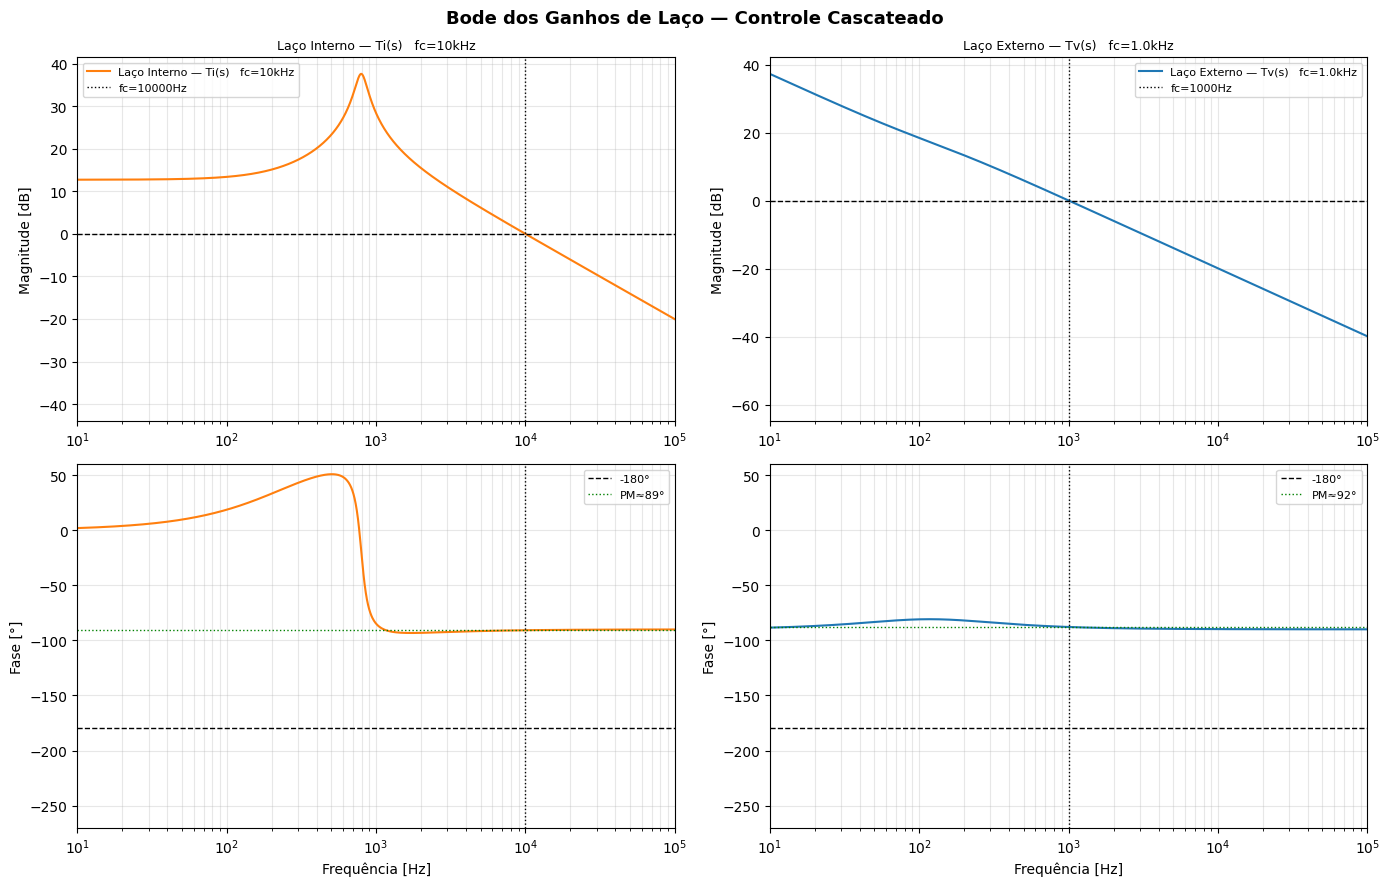

In [18]:
# ============================================================
# BODE DOS GANHOS DE LAÇO ABERTO
# ============================================================

# Laço interno: T_i(s) = Kp_i * Gid(s)   (controlador P)
Ti_s = Kp_i * Gid_s

# PI externo: Gcv(s) = Kp_v * (1 + omega_iv/s)
Gcv_s = Kp_v * (1 + omega_iv / (s + 1e-6))  # +1e-6 evita div/0 em DC

# Laço externo: T_v(s) = Gcv(s) * Geff(s)  (com laço interno ≈ 1)
Tv_s = Gcv_s * Geff_s

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, (T_s, fc, label, color) in enumerate([
        (Ti_s, f_ci, f'Laço Interno — Ti(s)   fc={f_ci/1e3:.0f}kHz', 'tab:orange'),
        (Tv_s, f_cv, f'Laço Externo — Tv(s)   fc={f_cv/1e3:.1f}kHz', 'tab:blue'),
]):
    mag_dB = 20*np.log10(np.abs(T_s) + 1e-15)
    ph_deg = np.degrees(np.angle(T_s))

    ax_m = axes[0, col]
    ax_m.semilogx(f_plot, mag_dB, color=color, lw=1.5, label=label)
    ax_m.axhline(0,  color='k', ls='--', lw=1)
    ax_m.axvline(fc, color='k', ls=':',  lw=1, label=f'fc={fc:.0f}Hz')
    ax_m.set_title(label, fontsize=9)
    ax_m.set_ylabel('Magnitude [dB]')
    ax_m.legend(fontsize=8)
    ax_m.grid(True, which='both', alpha=0.3)
    ax_m.set_xlim([10, 1e5])

    ax_p = axes[1, col]
    ax_p.semilogx(f_plot, ph_deg, color=color, lw=1.5)
    ax_p.axhline(-180, color='k', ls='--', lw=1, label='-180°')
    ax_p.axvline(fc,   color='k', ls=':',  lw=1)

    # Encontrar margem de fase no cruzamento (interpolação)
    idx_cross = np.argmin(np.abs(20*np.log10(np.abs(T_s) + 1e-15)))
    pm_actual = 180.0 + ph_deg[idx_cross]
    ax_p.axhline(-180 + pm_actual, color='green', ls=':', lw=1,
                 label=f'PM≈{pm_actual:.0f}°')
    ax_p.set_xlabel('Frequência [Hz]')
    ax_p.set_ylabel('Fase [°]')
    ax_p.set_ylim([-270, 60])
    ax_p.legend(fontsize=8)
    ax_p.grid(True, which='both', alpha=0.3)
    ax_p.set_xlim([10, 1e5])

plt.suptitle('Bode dos Ganhos de Laço — Controle Cascateado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CONSTRUÇÃO DO CIRCUITO
# ============================================================

def create_boost(Vin, L, C, R_load, Rsense, fsw, duty_init):
    """
    Boost converter com resistor de sensoriamento de corrente.
    Topologia:
      Vin → n_in → [Rsense] → n_sense → [L] → n_sw → (MOSFET p/ GND)
                                                     → [D1] → n_out → [C]//[R] → GND
    Corrente do indutor: IL = (V(n_in) - V(n_sense)) / Rsense
    """
    ckt  = ps.Circuit()
    n_in    = ckt.add_node('in')
    n_sense = ckt.add_node('sense')
    n_sw    = ckt.add_node('sw')
    n_out   = ckt.add_node('out')
    n_ctrl  = ckt.add_node('ctrl')

    ckt.add_voltage_source('Vin',   n_in,    -1, Vin)
    ckt.add_resistor('Rsns',        n_in,    n_sense, Rsense)
    ckt.add_inductor('L1',          n_sense, n_sw, L)

    mp = ps.MOSFETParams()
    mp.vth = 2.0
    mp.kp  = 10.0
    mp.g_off = 1e-6
    ckt.add_mosfet('M1', n_ctrl, n_sw, -1, mp)

    ckt.add_diode('D1', n_sw, n_out, g_on=100.0, g_off=1e-9)
    ckt.add_capacitor('C1',  n_out, -1, C)
    ckt.add_resistor('Rload', n_out, -1, R_load)

    pwm = ps.PWMParams()
    pwm.v_high   = 10.0
    pwm.v_low    = 0.0
    pwm.frequency = fsw
    pwm.duty     = duty_init
    ckt.add_pwm_voltage_source('Vpwm', n_ctrl, -1, pwm)

    nodes = {
        'n_in':    n_in,
        'n_sense': n_sense,
        'n_sw':    n_sw,
        'n_out':   n_out,
        'n_ctrl':  n_ctrl,
    }
    return ckt, nodes

# Teste rápido
ckt_test, _nd = create_boost(Vin, L, C, R_load, Rsense, fsw, D)
print(f'Circuito criado: {ckt_test.num_nodes()} nós, system_size={ckt_test.system_size()}')

Circuito criado: 5 nós, system_size=8


In [20]:
# ============================================================
# SIMULAÇÃO EM MALHA ABERTA
# ============================================================
n_periods_ol = 600
dt_ol = Tsw / 100

ckt_ol, nd_ol = create_boost(Vin, L, C, R_load, Rsense, fsw, D)
x0_ol = np.zeros(ckt_ol.system_size())
newton = ps.NewtonOptions()
newton.max_iterations = 120

t0 = time.time()
t_ol, st_ol, ok_ol, msg_ol = run_transient_compat(
    ckt_ol, 0.0, n_periods_ol*Tsw, dt_ol, x0_ol, newton)
print(f'Malha aberta: {"OK" if ok_ol else "FALHA"} — {msg_ol}')
print(f'Tempo: {time.time()-t0:.2f}s  |  Pontos: {len(t_ol)}')

if ok_ol and len(t_ol) > 0:
    st_ol = np.array(st_ol)
    t_ol  = np.array(t_ol)
    v_out_ol = st_ol[:, nd_ol['n_out']]
    i_L_ol   = (st_ol[:, nd_ol['n_in']] - st_ol[:, nd_ol['n_sense']]) / Rsense

    idx_ss = int(0.8 * len(t_ol))
    Vout_ol_avg  = float(np.mean(v_out_ol[idx_ss:]))
    Vout_theory  = Vin / Dp
    IL_ol_avg    = float(np.mean(i_L_ol[idx_ss:]))

    print(f'\nVout médio (RP): {Vout_ol_avg:.3f}V  |  Teórico: {Vout_theory:.3f}V  |  Erro: {(Vout_ol_avg-Vout_theory)/Vout_theory*100:.2f}%')
    print(f'IL médio (RP):   {IL_ol_avg:.3f}A   |  Nominal: {IL_nom:.3f}A')

Malha aberta: OK — Transient completed
Tempo: 0.61s  |  Pontos: 61763

Vout médio (RP): 23.834V  |  Teórico: 24.000V  |  Erro: -0.69%
IL médio (RP):   4.096A   |  Nominal: 4.167A


In [21]:
# ============================================================
# SIMULAÇÃO — CONTROLE CASCATEADO
# ============================================================

def simulate_cascaded(
    Vin, L, C, R_load, Rsense, fsw,
    V_ref, IL_max,
    Kp_i,          # ganho prop. do laço interno [duty/A]
    Kp_v, Ki_v,    # ganhos PI do laço externo [A/V], [A/(V·s)]
    D_min=0.05, D_max=0.85,
    n_periods=3000,
    dt_factor=100,
    outer_rate=5,        # laço externo atualiza a cada N períodos
    softstart_periods=200,
):
    """
    Controle em cascata:
    - Laço interno (P + feedforward):   d = D_ff + Kp_i*(I_ref - IL)
    - Laço externo (PI):               I_ref = Kp_v*ev + Ki_v*integral(ev)

    O feedforward D_ff = 1 - Vin/Vout_meas estabiliza o ponto de operação
    enquanto a correção proporcional fecha o laço de corrente.
    O laço externo PI garante erro nulo em regime permanente para Vout.
    """
    Tsw      = 1.0 / fsw
    dt_inner = Tsw / dt_factor
    dt_outer = outer_rate * Tsw

    ckt, nd = create_boost(Vin, L, C, R_load, Rsense, fsw, D_min)
    x = np.zeros(ckt.system_size())

    newton = ps.NewtonOptions()
    newton.max_iterations = 120

    d_current    = float(D_min)
    I_ref        = 0.0
    outer_integ  = 0.0      # integral do laço externo [A]
    # Limite anti-windup do integrador: I_ref ≤ IL_max
    outer_integ_max = IL_max / max(Ki_v, 1e-9)

    t_hist, vout_hist, iL_hist, duty_hist, iref_hist = [], [], [], [], []
    t = 0.0

    for k in range(n_periods):
        # --- Ramp de soft-start ---
        ramp = min(1.0, (k + 1) / max(1, softstart_periods))
        Vref_eff = V_ref * ramp

        # --- Simular um período ---
        times_p, states_p, ok, msg = run_transient_compat(
            ckt, t, t + Tsw, dt_inner, x, newton)
        if not ok:
            print(f'  Falha no período {k}: {msg}')
            break

        st_arr = np.array(states_p)
        x = st_arr[-1].copy()
        t += Tsw

        # --- Medição ---
        Vout_meas = float(np.mean(st_arr[:, nd['n_out']]))
        IL_meas   = float(np.mean(
            (st_arr[:, nd['n_in']] - st_arr[:, nd['n_sense']]) / Rsense
        ))

        # --- Laço externo (PI) — atualiza a cada outer_rate períodos ---
        if k % outer_rate == 0:
            ev           = Vref_eff - Vout_meas
            outer_integ += ev * dt_outer
            # Anti-windup por clamping
            outer_integ  = float(np.clip(outer_integ, 0.0, outer_integ_max))
            I_ref        = float(np.clip(
                Kp_v * ev + Ki_v * outer_integ,
                0.0, IL_max
            ))

        # --- Laço interno (P + feedforward) — atualiza todo período ---
        D_ff      = float(np.clip(1.0 - Vin / max(Vout_meas, Vin + 0.5), D_min, D_max))
        ei        = I_ref - IL_meas
        d_cmd     = D_ff + Kp_i * ei
        d_current = float(np.clip(d_cmd, D_min, D_max))
        ckt.set_pwm_duty('Vpwm', d_current)

        # --- Registro ---
        t_hist.append(t * 1e3)
        vout_hist.append(Vout_meas)
        iL_hist.append(IL_meas)
        duty_hist.append(d_current)
        iref_hist.append(I_ref)

        if k < 3 or k % 500 == 0:
            print(f'  k={k:4d}: Vout={Vout_meas:6.2f}V  IL={IL_meas:5.2f}A  '
                  f'I_ref={I_ref:5.2f}A  D={d_current:.3f}  D_ff={D_ff:.3f}')

    return {
        'time':  np.array(t_hist),
        'vout':  np.array(vout_hist),
        'iL':    np.array(iL_hist),
        'duty':  np.array(duty_hist),
        'iref':  np.array(iref_hist),
        'success': len(t_hist) == n_periods,
    }


print('Iniciando simulação cascateada...')
t0 = time.time()

res = simulate_cascaded(
    Vin, L, C, R_load, Rsense, fsw,
    V_ref=Vout,
    IL_max=3.0 * IL_nom,
    Kp_i=Kp_i,
    Kp_v=Kp_v,
    Ki_v=Ki_v,
    D_min=0.05, D_max=0.85,
    n_periods=3000,
    dt_factor=100,
    outer_rate=5,
    softstart_periods=200,
)
print(f'\nTempo total: {time.time()-t0:.1f}s  |  Sucesso: {res["success"]}')

Iniciando simulação cascateada...
  k=   0: Vout=  0.01V  IL= 0.31A  I_ref= 0.14A  D=0.050  D_ff=0.050
  k=   1: Vout=  0.09V  IL= 1.50A  I_ref= 0.14A  D=0.050  D_ff=0.050
  k=   2: Vout=  0.29V  IL= 2.68A  I_ref= 0.14A  D=0.050  D_ff=0.050
  k= 500: Vout= 23.65V  IL= 4.13A  I_ref= 4.15A  D=0.497  D_ff=0.493
  k=1000: Vout= 23.98V  IL= 4.21A  I_ref= 4.22A  D=0.504  D_ff=0.499
  k=1500: Vout= 24.00V  IL= 4.21A  I_ref= 4.23A  D=0.504  D_ff=0.500
  k=2000: Vout= 24.00V  IL= 4.21A  I_ref= 4.23A  D=0.504  D_ff=0.500
  k=2500: Vout= 24.00V  IL= 4.21A  I_ref= 4.23A  D=0.504  D_ff=0.500

Tempo total: 91.0s  |  Sucesso: True


REGIME PERMANENTE (últimos 20%)
  Vout médio:  24.0000 V  (ref=24.0V,  erro=-0.000%)
  IL médio:    4.2149 A   (nominal=4.167A)
  Duty médio:  0.5039    (teórico D=0.5000)


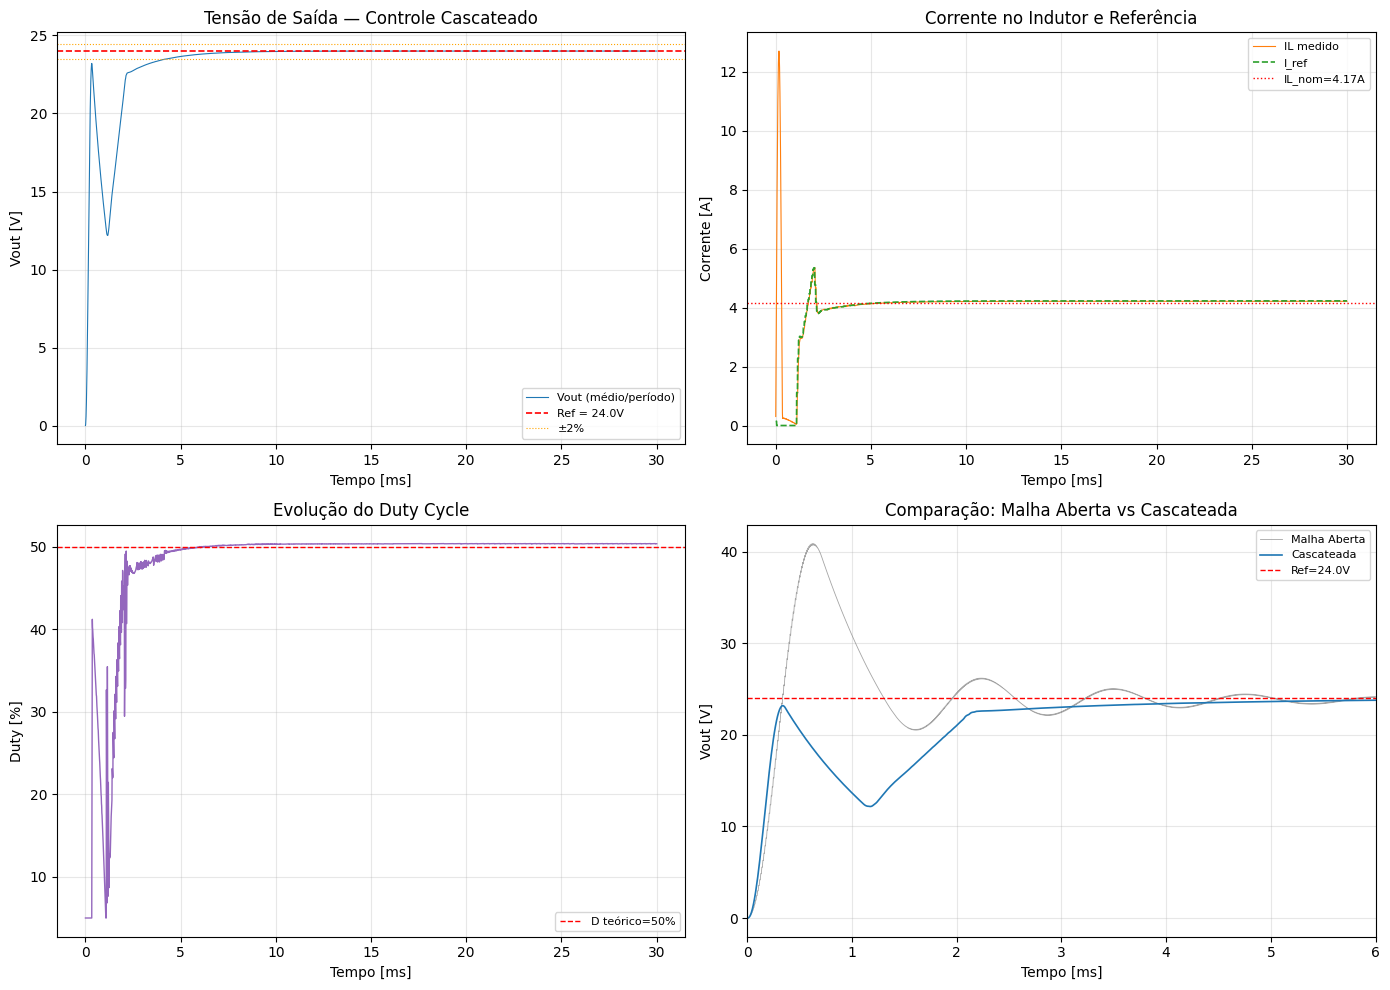

In [22]:
# ============================================================
# ANÁLISE E GRÁFICOS
# ============================================================
if res['success']:
    idx_ss = int(0.8 * len(res['vout']))
    Vout_ss   = float(np.mean(res['vout'][idx_ss:]))
    IL_ss     = float(np.mean(res['iL'][idx_ss:]))
    duty_ss   = float(np.mean(res['duty'][idx_ss:]))
    erro_V    = (Vout_ss - Vout) / Vout * 100

    print('REGIME PERMANENTE (últimos 20%)')
    print(f'  Vout médio:  {Vout_ss:.4f} V  (ref={Vout}V,  erro={erro_V:+.3f}%)')
    print(f'  IL médio:    {IL_ss:.4f} A   (nominal={IL_nom:.3f}A)')
    print(f'  Duty médio:  {duty_ss:.4f}    (teórico D={D:.4f})')

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Vout
    ax = axes[0, 0]
    ax.plot(res['time'], res['vout'], color='tab:blue', lw=0.8, label='Vout (médio/período)')
    ax.axhline(Vout, color='red', ls='--', lw=1.2, label=f'Ref = {Vout}V')
    ax.axhline(Vout*1.02, color='orange', ls=':', lw=0.8)
    ax.axhline(Vout*0.98, color='orange', ls=':', lw=0.8, label='±2%')
    ax.set_xlabel('Tempo [ms]')
    ax.set_ylabel('Vout [V]')
    ax.set_title('Tensão de Saída — Controle Cascateado')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Corrente
    ax = axes[0, 1]
    ax.plot(res['time'], res['iL'],   color='tab:orange', lw=0.8, label='IL medido')
    ax.plot(res['time'], res['iref'], color='tab:green',  lw=1.2, ls='--', label='I_ref')
    ax.axhline(IL_nom, color='red', ls=':', lw=1, label=f'IL_nom={IL_nom:.2f}A')
    ax.set_xlabel('Tempo [ms]')
    ax.set_ylabel('Corrente [A]')
    ax.set_title('Corrente no Indutor e Referência')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Duty
    ax = axes[1, 0]
    ax.plot(res['time'], res['duty']*100, color='tab:purple', lw=1)
    ax.axhline(D*100, color='red', ls='--', lw=1, label=f'D teórico={D:.0%}')
    ax.set_xlabel('Tempo [ms]')
    ax.set_ylabel('Duty [%]')
    ax.set_title('Evolução do Duty Cycle')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Comparação malha aberta vs fechada (Vout)
    ax = axes[1, 1]
    if ok_ol:
        ax.plot(t_ol*1e3, v_out_ol, color='tab:gray', lw=0.6, alpha=0.7, label='Malha Aberta')
    ax.plot(res['time'], res['vout'], color='tab:blue', lw=1.2, label='Cascateada')
    ax.axhline(Vout, color='red', ls='--', lw=1, label=f'Ref={Vout}V')
    ax.set_xlabel('Tempo [ms]')
    ax.set_ylabel('Vout [V]')
    ax.set_title('Comparação: Malha Aberta vs Cascateada')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, min(res['time'][-1], t_ol[-1]*1e3) if ok_ol else res['time'][-1]])

    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================
# RESUMO FINAL
# ============================================================
print('='*70)
print('RESUMO — BOOST CONVERTER COM CONTROLE CASCATEADO')
print('='*70)

print('\n1. ESPECIFICAÇÕES')
print(f'   Vin={Vin}V  Vout={Vout}V  P={Pout}W  fsw={fsw/1e3:.0f}kHz')

print('\n2. COMPONENTES')
print(f'   L={L*1e6:.0f}µH  C={C*1e6:.0f}µF  R={R_load:.2f}Ω  Rsense={Rsense*1e3:.0f}mΩ')

print('\n3. MODELO DE PEQUENOS SINAIS')
print(f'   f0={f0:.0f}Hz  Q={Q:.2f}  fz_RHP={f_z_rhp:.0f}Hz  fz_LHP={f_z_lhp:.0f}Hz')

print('\n4. CONTROLADORES')
print(f'   Laço interno P:  Kp_i={Kp_i:.4f} duty/A  fci={f_ci/1e3:.0f}kHz  PM≈{PM_inner:.0f}°')
print(f'   Laço externo PI: Kp_v={Kp_v:.4f} A/V  Ki_v={Ki_v:.1f} A/(V·s)  fcv={f_cv:.0f}Hz  PM≈{PM_outer_total:.0f}°')

print('\n5. SIMULAÇÃO')
if ok_ol:
    print(f'   Malha Aberta:   Vout={Vout_ol_avg:.3f}V  erro={(Vout_ol_avg-Vout)/Vout*100:+.2f}%  IL={IL_ol_avg:.3f}A')
if res['success']:
    print(f'   Cascateada:     Vout={Vout_ss:.4f}V  erro={erro_V:+.3f}%  IL={IL_ss:.3f}A  D={duty_ss:.4f}')

print('='*70)

RESUMO — BOOST CONVERTER COM CONTROLE CASCATEADO

1. ESPECIFICAÇÕES
   Vin=12.0V  Vout=24.0V  P=50.0W  fsw=100kHz

2. COMPONENTES
   L=100µH  C=100µF  R=11.52Ω  Rsense=10mΩ

3. MODELO DE PEQUENOS SINAIS
   f0=796Hz  Q=5.76  fz_RHP=4584Hz  fz_LHP=276Hz

4. CONTROLADORES
   Laço interno P:  Kp_i=0.2601 duty/A  fci=10kHz  PM≈89°
   Laço externo PI: Kp_v=1.2686 A/V  Ki_v=797.1 A/(V·s)  fcv=1000Hz  PM≈83°

5. SIMULAÇÃO
   Malha Aberta:   Vout=23.834V  erro=-0.69%  IL=4.096A
   Cascateada:     Vout=24.0000V  erro=-0.000%  IL=4.215A  D=0.5039
